In [24]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [25]:
def compute_ec_ej_2d(u_even,u_odd,N,femsystem,theta_at_dofs):
    # Compute integrated area for normalization, as in 2DZeroPoint.py
    integrated_area = femsystem.integrate(lambda u, grad_u, x: u, theta_at_dofs)
    material = N / integrated_area
    G_mat, P_int = femsystem.get_greens_kernel()

    def alpha(u, G_mat, P_int):
        return 1/material * femsystem.double_integral(
            lambda u1, a, b, c, d: u1**2,
            lambda u1, a, b, c, d: u1**2,
            G_mat, P_int, u, u,
        )

    def beta(u1, u2, G_mat, P_int):
        return 1/material * femsystem.double_integral(
            lambda u1, a, b, c, d: u1**2,
            lambda a, b, u2, c, d: u2**2,
            G_mat, P_int, u1, u2,
        )

    def gamma(u1, u2, G_mat, P_int):
        return 1/material * femsystem.double_integral(
            lambda u1, a, u2, c, d: u1 * u2,
            lambda u1, b, u2, c, d: u1 * u2,
            G_mat, P_int, u1, u2,
        )

    # Lambda terms
    lambda_y = 2 * beta(u_even, u_odd, G_mat, P_int) - alpha(u_even, G_mat, P_int) - alpha(u_odd, G_mat, P_int)
    lambda_x = lambda_y + 4 * gamma(u_even, u_odd, G_mat, P_int)
    print(lambda_y, lambda_x)

    # Same E(u) as 2DTwoModesOpt.py: epsilon(u) + (N - 1) * alpha(u) — not epsilon + alpha.
    # hz = E_+(even) - E_-(odd). Using only +alpha makes hz (and EJ) wrong by O(N*alpha).
    def laplacian(u, grad_u, x):
        return -1 * jnp.sum(grad_u**2, axis=0)

    def u_squared(u, grad_u, u2, grad_u2, x):
        return u**2

    def theta_func(u, grad_u, u2, grad_u2, x):
        return u2

    def epsilon_func(u_global, G_mat, P_int, theta_at_dofs):
        kinetic = -4 * femsystem.integrate(laplacian, u_global)
        potential = -2 * femsystem.double_integral(
            u_squared, theta_func, G_mat, P_int, u_global, theta_at_dofs
        )
        return kinetic + potential

    def E_mode(u_global, G_mat, P_int, theta_at_dofs):
        return epsilon_func(u_global, G_mat, P_int, theta_at_dofs) + (N - 1) * alpha(u_global, G_mat, P_int)

    E_plus = E_mode(u_even, G_mat, P_int, theta_at_dofs)
    E_minus = E_mode(u_odd, G_mat, P_int, theta_at_dofs)
    hz = E_plus - E_minus

    # Charging energy EC
    E_C_computed = lambda_x 

    # Josephson energy E_J: same convention as 2DTwoModesOpt.py (E_J = -(hz/2) * N)
    E_J_computed = -0.5 * hz * N

    print(integrated_area)

    return E_C_computed,E_J_computed

In [26]:
pickled_obj = {}

with open('./../allplots/square10sep20num100/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
n,N,coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]
# E_J,E_C = pickled_obj["E_J"],pickled_obj["E_C"]

E_C_computed,E_J_computed = compute_ec_ej_2d(u_even,u_odd,N,femsystem,theta_at_dofs)
E_C,E_J = E_C_computed,E_J_computed

print(f"EC: {E_C} (Original) vs. {E_C_computed} (Computed)")
print(f"EJ: {E_J} (Original) vs. {E_J_computed} (Computed)")
# Number of degrees of freedom
print(f"Degrees of Freedom: {len(theta_at_dofs)}")

# List all fields (keys) in pickled_obj and their corresponding data types (and shapes for arrays)

for key, val in pickled_obj.items():
    data_type = type(val)
    try:
        shape = val.shape
    except AttributeError:
        shape = None
    # Print a summary for each entry
    if shape:
        print(f"{key}: type={data_type}, shape={shape}")
    else:
        print(f"{key}: type={data_type}")

/Users/vincentcai/Desktop/cqednumerics/jax-gpu/lib/python3.9/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/vincentcai/Desktop/cqednumerics/jax-gpu/lib/python3.9/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


-0.00018587708 1.0310432
211.77405
EC: 1.0310431718826294 (Original) vs. 1.0310431718826294 (Computed)
EJ: 2.3893356323242188 (Original) vs. 2.3893356323242188 (Computed)
Degrees of Freedom: 3881
parameters: type=<class 'dict'>
times: type=<class 'dict'>
n: type=<class 'int'>
E_J: type=<class 'jaxlib.xla_extension.ArrayImpl'>
E_C: type=<class 'jaxlib.xla_extension.ArrayImpl'>
e0: type=<class 'jaxlib.xla_extension.ArrayImpl'>
objective: type=<class 'jaxlib.xla_extension.ArrayImpl'>
theta_at_dofs: type=<class 'jaxlib.xla_extension.ArrayImpl'>, shape=(3881,)
integrated_area: type=<class 'jaxlib.xla_extension.ArrayImpl'>
coeffs: type=<class 'jaxlib.xla_extension.ArrayImpl'>, shape=(50,)
u_even: type=<class 'jaxlib.xla_extension.ArrayImpl'>, shape=(3881,)
u_odd: type=<class 'jaxlib.xla_extension.ArrayImpl'>, shape=(3881,)
femsystem: type=<class 'FEMSystem.FEMSystem'>
totalTime: type=<class 'float'>
lambda_y_val: type=<class 'jaxlib.xla_extension.ArrayImpl'>


# Find Qubit Frequency

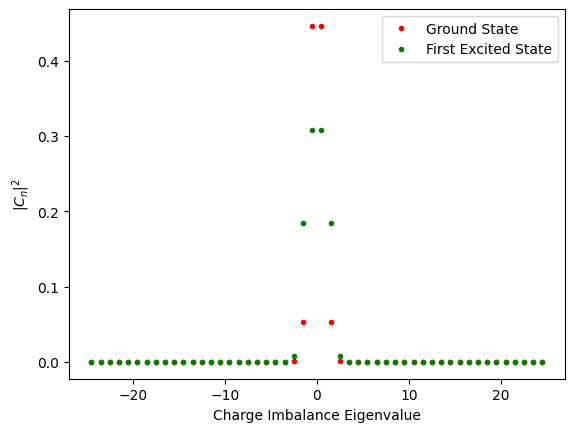

Qubit Frequency: 1.875546932220459


In [28]:
# Create the Hamiltonian Operator over Truncated Basis, to find eigenvectors for first excited state
def get_matrixel_and_qubit_freq(n,E_J,E_C,plot=False,coeffs=None):
    # Copy these three matrix construction functions from 3DTwoModesOpt.py
    x = (n-1)/2 - jnp.arange(n) # Charge Imbalance Eigenvalue, centered at 0 

    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)

    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 

    def cos_phi(n):
        return off_diag(n,1) / 2

    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    # Find Eigenvalues and Eigenvectors
    eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

    # Plot the ground state, first eigenvector
    ground_state_coeffs = eigenvectors[:,0] / jnp.sqrt(jnp.sum(eigenvectors[:,0]**2))
    first_excited_coeffs = eigenvectors[:,1] / jnp.sqrt(jnp.sum(eigenvectors[:,1]**2))

    if plot: 
        ground_state_coeffs_from_optimization = coeffs / jnp.sqrt(jnp.sum(coeffs**2))
        plt.plot(x,ground_state_coeffs**2,".",color="red",label="Ground State")
        #plt.plot(x,ground_state_coeffs_from_optimization**2,"x",color="grey",label="Ground State (Optimization Loop)")
        plt.plot(x,first_excited_coeffs**2,".",color="green",label="First Excited State")
        plt.xlabel("Charge Imbalance Eigenvalue")
        plt.ylabel("$|C_n|^2$")
        plt.legend()
        plt.show()
    
    # Get the frequency of the qubit
    sorted_eigenvalues = jnp.sort(eigenvalues)
    omega_q = sorted_eigenvalues[1] - sorted_eigenvalues[0]

    return jnp.sum(first_excited_coeffs * ground_state_coeffs * x), omega_q # x is the charge imbalance eigenvalue

mat_el,E_q = get_matrixel_and_qubit_freq(n,E_J,E_C,plot=True,coeffs=coeffs)
print(f"Qubit Frequency: {E_q}")

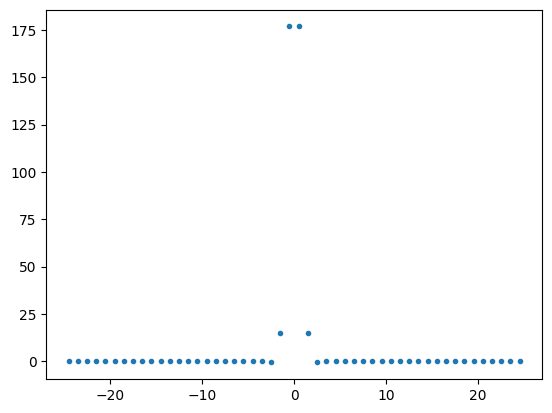

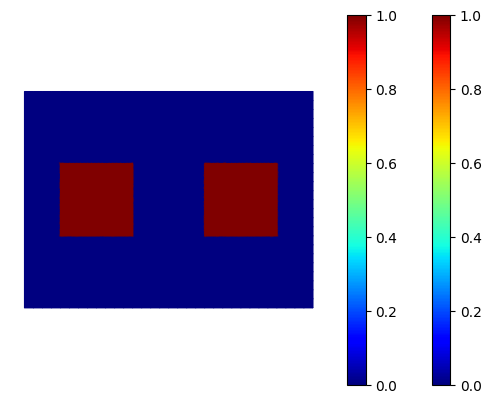

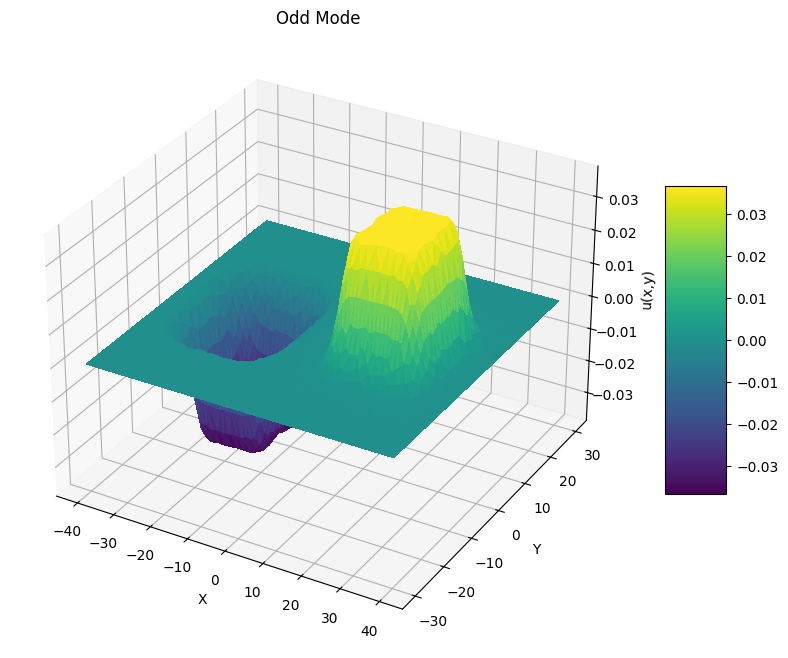

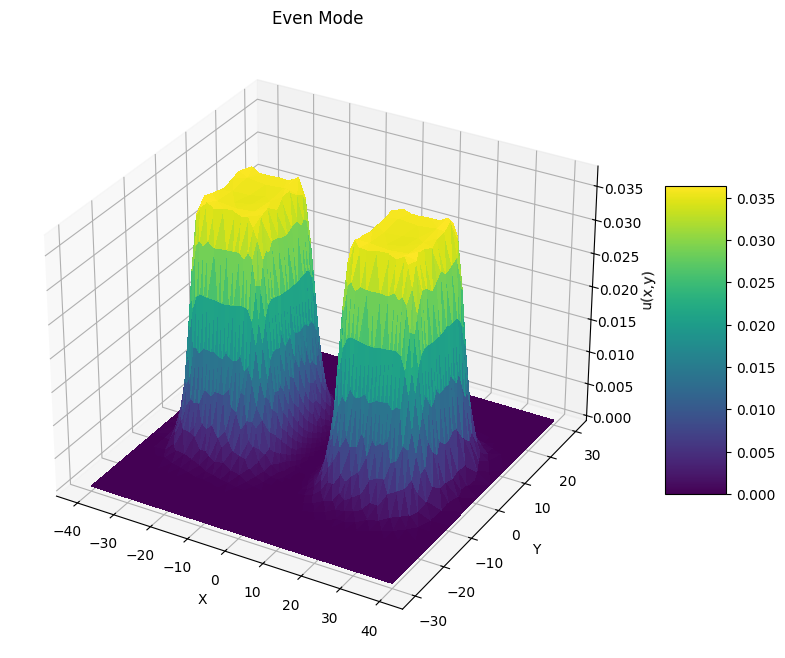

In [60]:
x = (n-1)/2 - jnp.arange(n)
plt.plot(x,coeffs,".")
femsystem.plot_at_interior_2d(theta_at_dofs[femsystem.interior_dofs])
femsystem.plot_at_interior_2d_in3d(u_odd_interior,plot_title="Odd Mode")
femsystem.plot_at_interior_2d_in3d(u_even_interior,plot_title="Even Mode")

In [ ]:
integrated_area = femsystem.integrate(lambda u, grad_u, x: u, theta_at_dofs)
G_mat, P_int = femsystem.get_greens_kernel()

# U_{++++} or U_{----}, Really N * \alpha
def alpha(u, G_mat, P_int):
    return integrated_area * femsystem.double_integral(
        lambda u1, a, b, c, d: u1**2,
        lambda u1, a, b, c, d: u1**2,
        G_mat, P_int, u, u,
    )

# U_{+--+} = U{-++-} - Remember middle two are wrt to y, Outer two wrt to x, from notation used in doc
def beta(u1_arg, u2_arg, G_mat, P_int):
    return integrated_area * femsystem.double_integral(
        lambda u1, a, b, c, d: u1**2,
        lambda a, b, u2, c, d: u2**2,
        G_mat, P_int, u1_arg, u2_arg,
    )

# U_{++--} = U{+-+-}
def gamma(u1_arg, u2_arg, G_mat, P_int):
    return integrated_area * femsystem.double_integral(
        lambda u1, a, u2, c, d: u1 * u2,
        lambda u1, b, u2, c, d: u1 * u2,
        G_mat, P_int, u1_arg, u2_arg,
    )

lambda_y = (
    2 * beta(u_even, u_odd, G_mat, P_int)
    - alpha(u_even, G_mat, P_int)
    - alpha(u_odd, G_mat, P_int)
)
lambda_x = lambda_y + 4 * gamma(u_even, u_odd, G_mat, P_int)
print(lambda_y, lambda_x)

/scratch/gpfs/AROD/vc9839/finite-island-cqed/jax-gpu/lib64/python3.9/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/scratch/gpfs/AROD/vc9839/finite-island-cqed/jax-gpu/lib64/python3.9/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


-0.027877808 198.76384


: 

# Visualize Sweep

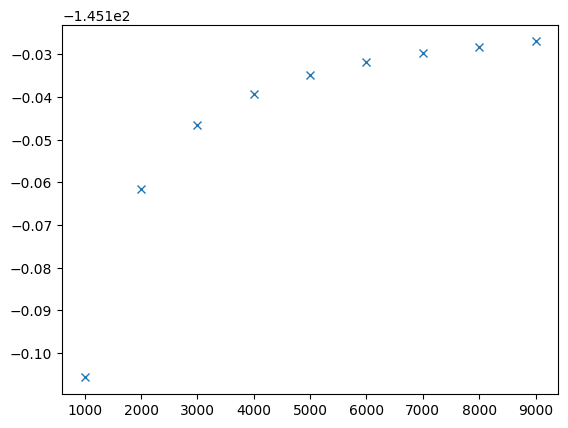

In [ ]:
pickled_objs = []
separations = np.arange(1,29,3)
Ns = np.arange(1000,10000,1000)

# Get all pickled objects
for N in Ns:
    pickled_obj = {}

    with open(f'./phasetransitiontry4/{N}/results.pkl', 'rb') as f:
        pickled_obj= pickle.load(f)

    pickled_objs.append(pickled_obj)

energies = [p["objective"] for p in pickled_objs]
coeffs_per_sep = np.array([p["coeffs"] for p in pickled_objs])
n = pickled_objs[0]['n']
x = (n-1)/2 - jnp.arange(n)
plt.plot(Ns,energies,"x")

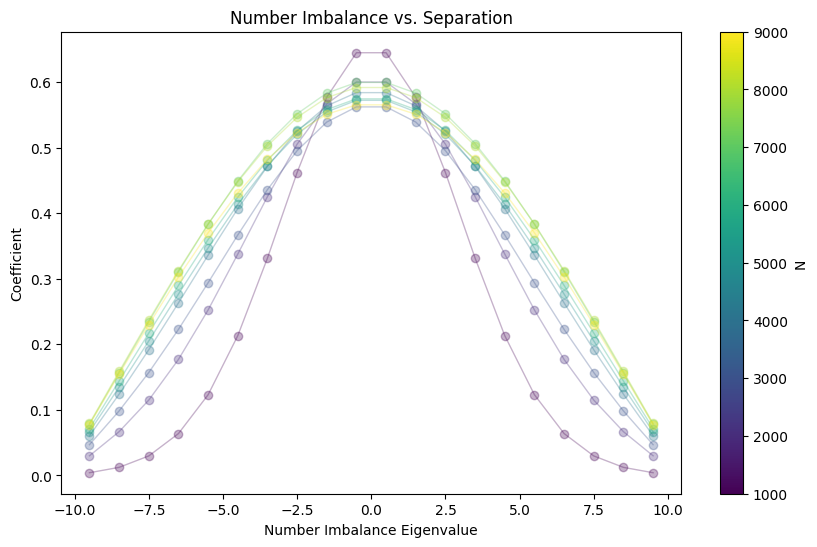

In [ ]:
# 3. Choose Colormap and Normalize Color Values
# Select a colormap (e.g., 'viridis')
cmap = plt.get_cmap('viridis')

color_values = Ns 
num_plots = len(color_values)

# Normalize the color values to range [0, 1] for the colormap
norm = plt.Normalize(vmin=np.min(color_values), vmax=np.max(color_values))

# 4. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

middle = 10

# Iterate and Plot each line
for i in range(num_plots):
    # Get the color for the i-th plot from the colormap
    line_color = cmap(norm(color_values[i]))

    # Plot the line with:
    # - `color`: Based on the auxiliary array
    # - `alpha`: Transparency (e.g., 0.1 to 0.5) to reveal overlap/density

    s,e = len(x) // 2 - middle, len(x) //2 + middle

    ax.plot(x[s:e], coeffs_per_sep[i, s:e],color=line_color, marker="o", linestyle="-",alpha=0.3, linewidth=1)

# 5. Add a Colorbar for Reference
# The 'heatmap' effect is due to density, but a colorbar is needed
# to explain what the color of the individual lines represents.
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Needs to be set to an empty array for Matplotlib < 3.1
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('N')

# 6. Final Touches
ax.set_title(f'Number Imbalance vs. N')
ax.set_ylabel('Coefficient')
ax.set_xlabel('Number Imbalance Eigenvalue')
# ax.set_yscale('log')
plt.show()

In [10]:
# Plot Energy




Cell types in file: ['vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'triangle6', 'triangle6', 'triangle6', 'triangle6', 'triangle6']


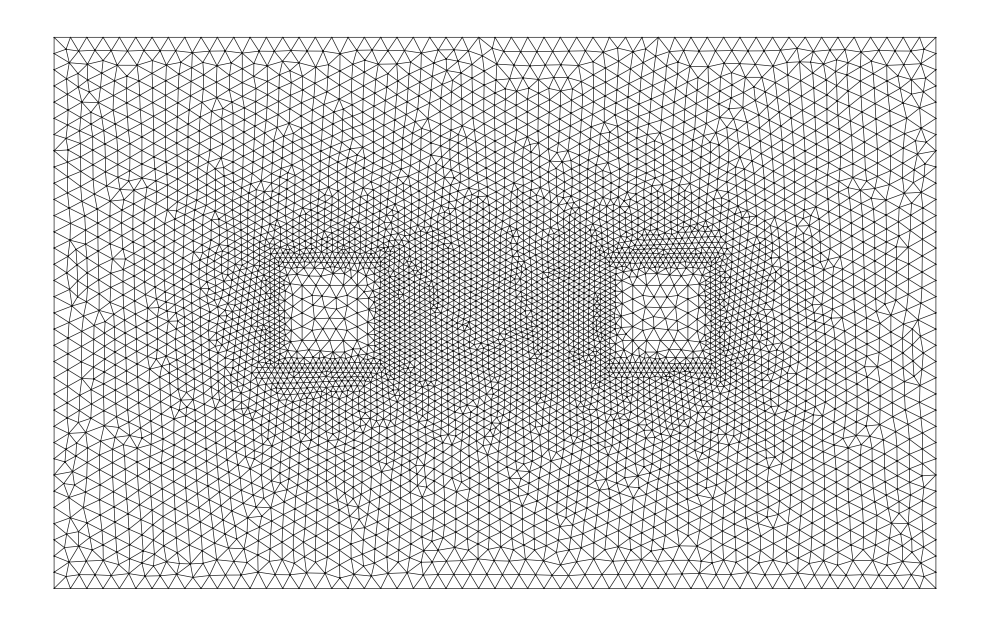

In [20]:
# Load in a .msh file and visualize in 2D
import meshio
import matplotlib.pyplot as plt
import numpy as np

# Load the .msh file
mesh = meshio.read('./../allplots/rabilondonfinal//custommesh.msh')

# Visualize the 2D mesh: show all triangle-like cells and nodes
points = mesh.points[:, :2]  # only x, y
print("Cell types in file:", [cb.type for cb in mesh.cells])

triangles_list = []
for cb in mesh.cells:
    ctype = cb.type

    # Standard linear triangles
    if ctype == "triangle":
        triangles_list.append(cb.data[:, :3])

    # Higher-order triangles from Gmsh (triangle6/triangle10/...) use first 3 corner nodes
    elif ctype.startswith("triangle"):
        triangles_list.append(cb.data[:, :3])

    # If mesh is quad-based, split each quad into 2 triangles for plotting
    elif ctype == "quad":
        q = cb.data
        t1 = q[:, [0, 1, 2]]
        t2 = q[:, [0, 2, 3]]
        triangles_list.extend([t1, t2])

if not triangles_list:
    raise ValueError(f"No 2D cells found. Available cell types: {[cb.type for cb in mesh.cells]}")

triangles = np.vstack(triangles_list)

# Plot mesh edges efficiently (no labels, axis, or legend)
fig, ax = plt.subplots(figsize=(10, 10))
ax.triplot(points[:, 0], points[:, 1], triangles, color="k", linewidth=0.5, alpha=0.9)
# ax.scatter(points[:, 0], points[:, 1], c="r", s=6, alpha=0.6)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


Cell types in file: ['vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'vertex', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'line3', 'triangl

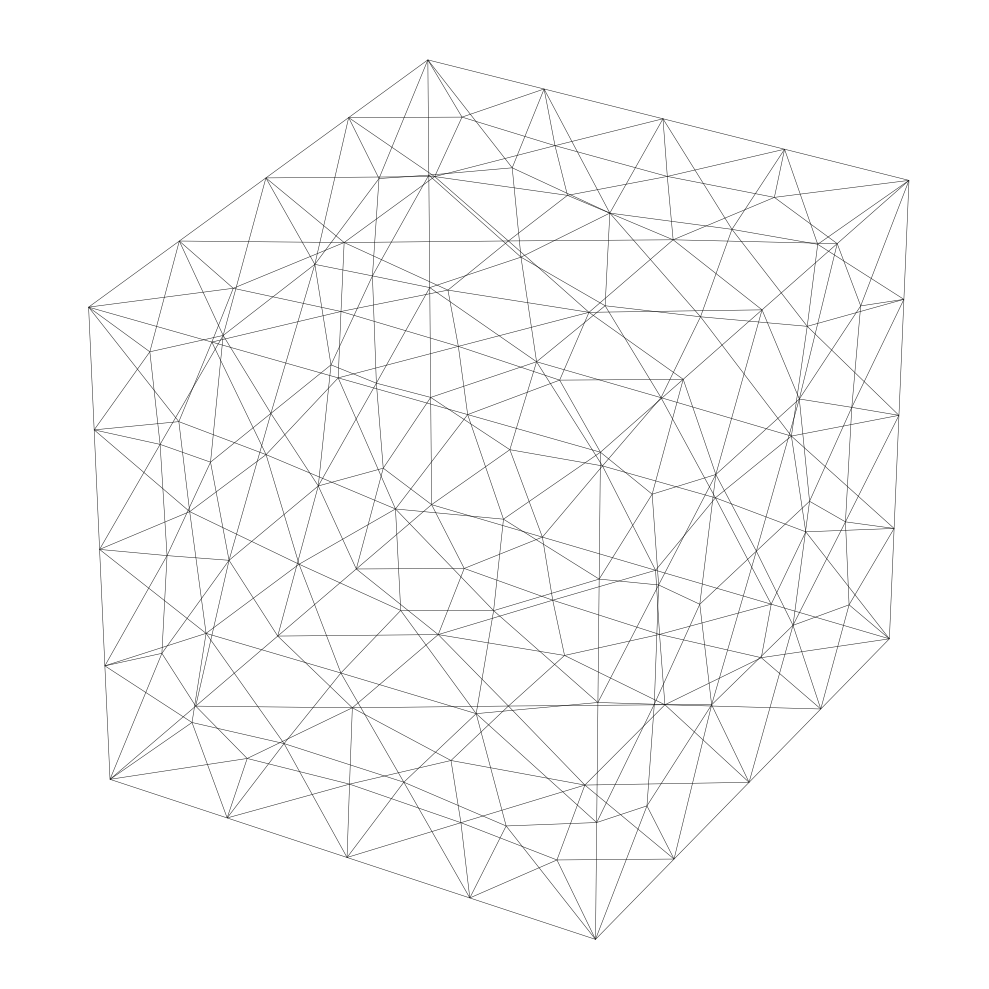

In [19]:
# Load in a .msh file and visualize in 3D
import meshio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Load the .msh file (change path as needed)

mesh = meshio.read('./../../3D/allplots/heightsweep4/height11/custommesh.msh')


points = mesh.points[:, :3]  # x, y, z
print("Cell types in file:", [cb.type for cb in mesh.cells])

# --------- collect volume elements ----------
tets_list = []
hex_list = []

for cb in mesh.cells:
    ctype = cb.type

    # Linear tetra
    if ctype == "tetra":
        tets_list.append(cb.data[:, :4])

    # Higher-order tetra (tetra10, tetra20, ...)
    elif ctype.startswith("tetra"):
        tets_list.append(cb.data[:, :4])  # first 4 are corner nodes

    # Linear hex
    elif ctype == "hexahedron":
        hex_list.append(cb.data[:, :8])

    # Higher-order hex (hexahedron20, hexahedron27, ...)
    elif ctype.startswith("hexahedron"):
        hex_list.append(cb.data[:, :8])   # first 8 are corner nodes

if not tets_list and not hex_list:
    raise ValueError(f"No 3D volume cells found. Available: {[cb.type for cb in mesh.cells]}")

# --------- extract boundary triangles ----------
# For tetra: each tet has 4 triangular faces.
tet_boundary_faces = []
if tets_list:
    tets = np.vstack(tets_list)
    tet_faces = np.vstack([
        tets[:, [0, 1, 2]],
        tets[:, [0, 1, 3]],
        tets[:, [0, 2, 3]],
        tets[:, [1, 2, 3]],
    ])
    # faces appearing once are boundary faces
    key = np.sort(tet_faces, axis=1)
    uniq, counts = np.unique(key, axis=0, return_counts=True)
    tet_boundary_faces = uniq[counts == 1]

# For hex: convert each quad face -> 2 triangles and keep boundary quads by counting
hex_boundary_tris = []
if hex_list:
    hexes = np.vstack(hex_list)

    # 6 quad faces per hex
    hex_quads = np.vstack([
        hexes[:, [0, 1, 2, 3]],
        hexes[:, [4, 5, 6, 7]],
        hexes[:, [0, 1, 5, 4]],
        hexes[:, [1, 2, 6, 5]],
        hexes[:, [2, 3, 7, 6]],
        hexes[:, [3, 0, 4, 7]],
    ])

    key = np.sort(hex_quads, axis=1)
    uniq, counts = np.unique(key, axis=0, return_counts=True)
    boundary_quads = uniq[counts == 1]

    # split each quad into 2 triangles
    t1 = boundary_quads[:, [0, 1, 2]]
    t2 = boundary_quads[:, [0, 2, 3]]
    hex_boundary_tris = np.vstack([t1, t2])

# Combine all boundary triangles
all_tris = []
if len(tet_boundary_faces) > 0:
    all_tris.append(tet_boundary_faces)
if len(hex_boundary_tris) > 0:
    all_tris.append(hex_boundary_tris)

boundary_tris = np.vstack(all_tris)

# --------- build boundary edge set for wireframe plotting ----------
edges = np.vstack([
    boundary_tris[:, [0, 1]],
    boundary_tris[:, [1, 2]],
    boundary_tris[:, [2, 0]],
])
edges = np.sort(edges, axis=1)
edges = np.unique(edges, axis=0)

segments = np.stack([points[edges[:, 0]], points[edges[:, 1]]], axis=1)

# --------- plot ----------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

lc = Line3DCollection(segments, colors='k', linewidths=0.35, alpha=0.9)
ax.add_collection3d(lc)

# Auto scale axes
mins = points.min(axis=0)
maxs = points.max(axis=0)
ax.set_xlim(mins[0], maxs[0])
ax.set_ylim(mins[1], maxs[1])
ax.set_zlim(mins[2], maxs[2])

# Equal-ish aspect for 3D
ax.set_box_aspect((maxs - mins + 1e-12))

# Clean look like your 2D plot
ax.set_axis_off()
plt.tight_layout()
plt.show()

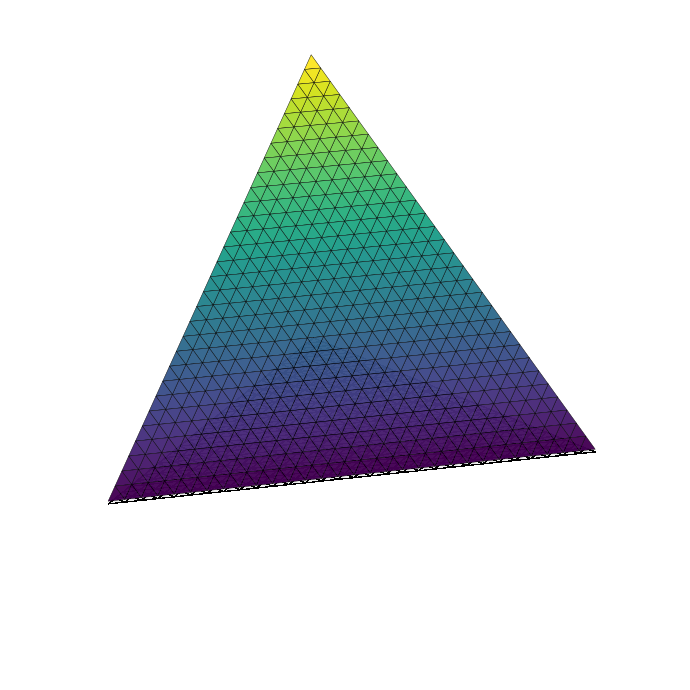